# AOL MACHINE LEARNING GROUP 6
MEMBERS: 1.Matthew Farrell Kurniawan - 2702280850, 2.Fidelis Yoga Pradipta - 2702296224, 3.Jonathan Ryan Wijaya - 2702279350, 4.Rowan Walyata Alfajri - 2702295663

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [31]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Data Understanding

In [32]:
# Finding data type and understanding how big the data is
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [33]:
# Understanding numerical data in statistical manner
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [34]:
# Finding null
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [35]:
# Cleaning data because of its small null sizes, we can just delete the data
df_cleaned = df.dropna(subset=['Teacher_Quality', 'Parental_Education_Level','Distance_from_Home'])
df_cleaned.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [36]:
# Dividing columns into numerical and categorical
cat_cols = []
num_cols = []
for i in df.columns:
        if 'int' in str(df_cleaned[i].dtype):
            num_cols.append(i)
        else:
            cat_cols.append(i)

print(f'Categorical: {cat_cols}')
print(f'Numeric: {num_cols}')

Categorical: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Numeric: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [37]:
# Finding unique value in categorical data
for col in cat_cols:
    print(f"Unique values in {col}: {df_cleaned[col].unique()}")

Unique values in Parental_Involvement: ['Low' 'Medium' 'High']
Unique values in Access_to_Resources: ['High' 'Medium' 'Low']
Unique values in Extracurricular_Activities: ['No' 'Yes']
Unique values in Motivation_Level: ['Low' 'Medium' 'High']
Unique values in Internet_Access: ['Yes' 'No']
Unique values in Family_Income: ['Low' 'Medium' 'High']
Unique values in Teacher_Quality: ['Medium' 'High' 'Low']
Unique values in School_Type: ['Public' 'Private']
Unique values in Peer_Influence: ['Positive' 'Negative' 'Neutral']
Unique values in Learning_Disabilities: ['No' 'Yes']
Unique values in Parental_Education_Level: ['High School' 'College' 'Postgraduate']
Unique values in Distance_from_Home: ['Near' 'Moderate' 'Far']
Unique values in Gender: ['Male' 'Female']


In [38]:
# Mapping categorical values to numeric values
mapping_yes_no = {'Yes': 1, 'No': 0}
mapping_low_medium_high = {'Low': 0, 'Medium': 1, 'High': 2}
mapping_negative_neutral_positive = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

# Apply mappings to the respective columns
df_cleaned['Internet_Access'] = df['Internet_Access'].replace(mapping_yes_no)
df_cleaned['Extracurricular_Activities'] = df['Extracurricular_Activities'].replace(mapping_yes_no)
df_cleaned['Learning_Disabilities'] = df['Learning_Disabilities'].replace(mapping_yes_no)

df_cleaned['Parental_Involvement'] = df['Parental_Involvement'].replace(mapping_low_medium_high)
df_cleaned['Access_to_Resources'] = df['Access_to_Resources'].replace(mapping_low_medium_high)
df_cleaned['Motivation_Level'] = df['Motivation_Level'].replace(mapping_low_medium_high)
df_cleaned['Family_Income'] = df['Family_Income'].replace(mapping_low_medium_high)
df_cleaned['Teacher_Quality'] = df['Teacher_Quality'].replace(mapping_low_medium_high)
df_cleaned['Distance_from_Home'] = df['Distance_from_Home'].replace(mapping_low_medium_high)

df_cleaned['Peer_Influence'] = df['Peer_Influence'].replace(mapping_negative_neutral_positive)

# Checking the transformed DataFrame
print(df_cleaned.head())

   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     0                    2   
1             19          64                     0                    1   
2             24          98                     1                    1   
3             29          89                     0                    1   
4             19          92                     1                    1   

   Extracurricular_Activities  Sleep_Hours  Previous_Scores  Motivation_Level  \
0                           0            7               73                 0   
1                           0            8               59                 0   
2                           1            7               91                 1   
3                           1            8               98                 1   
4                           1            6               65                 1   

   Internet_Access  Tutoring_Sessions  Family_Income  Teacher_

C:\Users\Ryan's PC\AppData\Local\Temp\ipykernel_20484\1212645303.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Internet_Access'] = df['Internet_Access'].replace(mapping_yes_no)
C:\Users\Ryan's PC\AppData\Local\Temp\ipykernel_20484\1212645303.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Extracurricular_Activities'] = df['Extracurricular_Activities'].replace(mapping_yes_no)
C:\Users\Ryan's PC\AppData\Local\Temp\ipykernel_20484\1212645303.py:9: SettingWithCopyWarning: 
A va

We decided to change some categorical data that seems logically relevant to numerical data to make the best model possible

# Feature Engineering
For data preprocessing in supervised learning

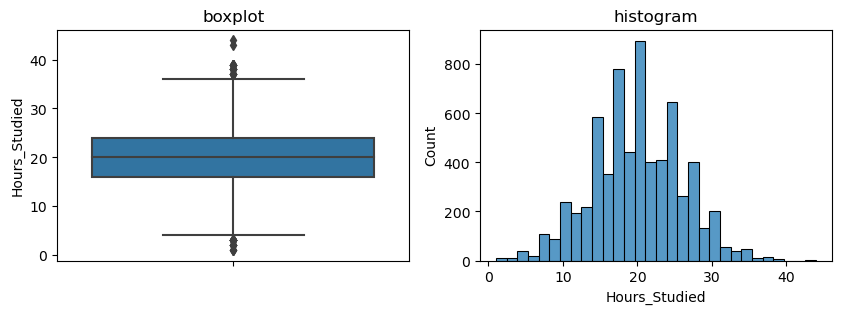

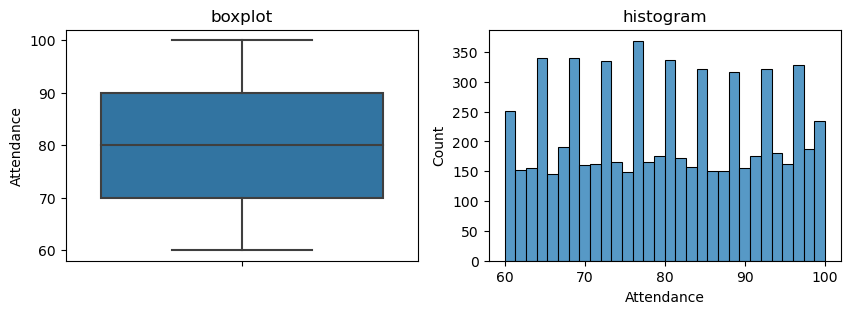

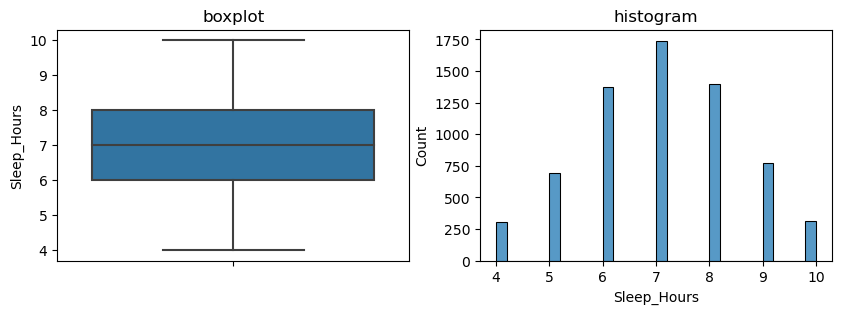

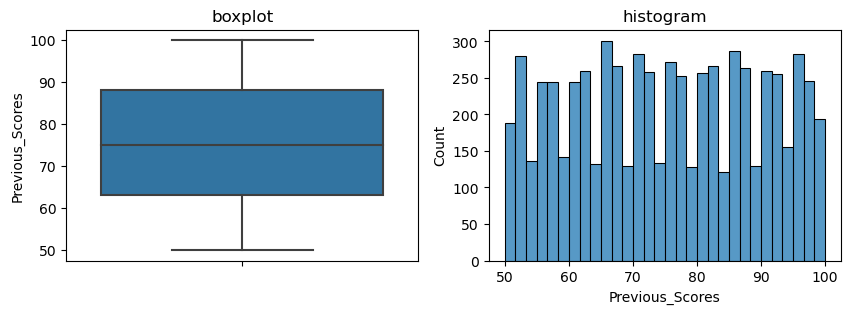

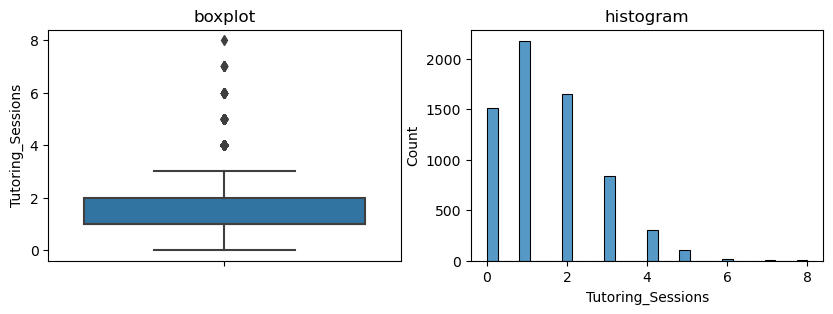

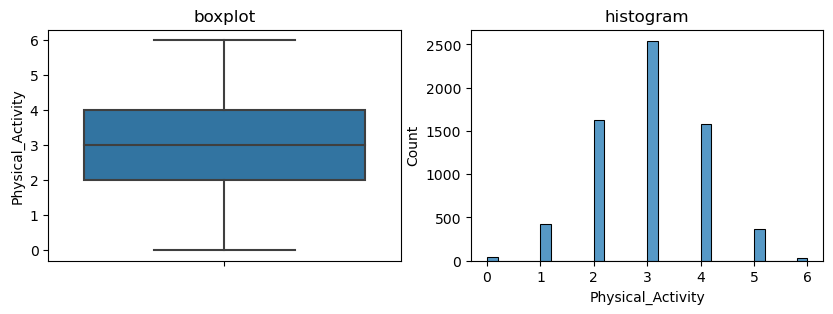

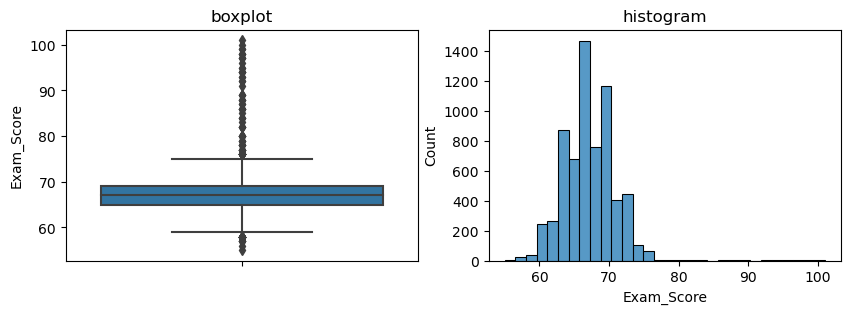

In [39]:
# Visualisation for finding outliers and distribution
def outliers(df_cleaned, columns):
    for col in columns:
        plt.figure(figsize = (10,3))
        
        plt.subplot(1,2,1)
        sns.boxplot(y=df[col])
        plt.title('boxplot')
        
        plt.subplot(1,2,2)
        sns.histplot(df[col], bins=30)
        plt.title('histogram')
        
        plt.show()
outliers(df_cleaned[num_cols],num_cols)

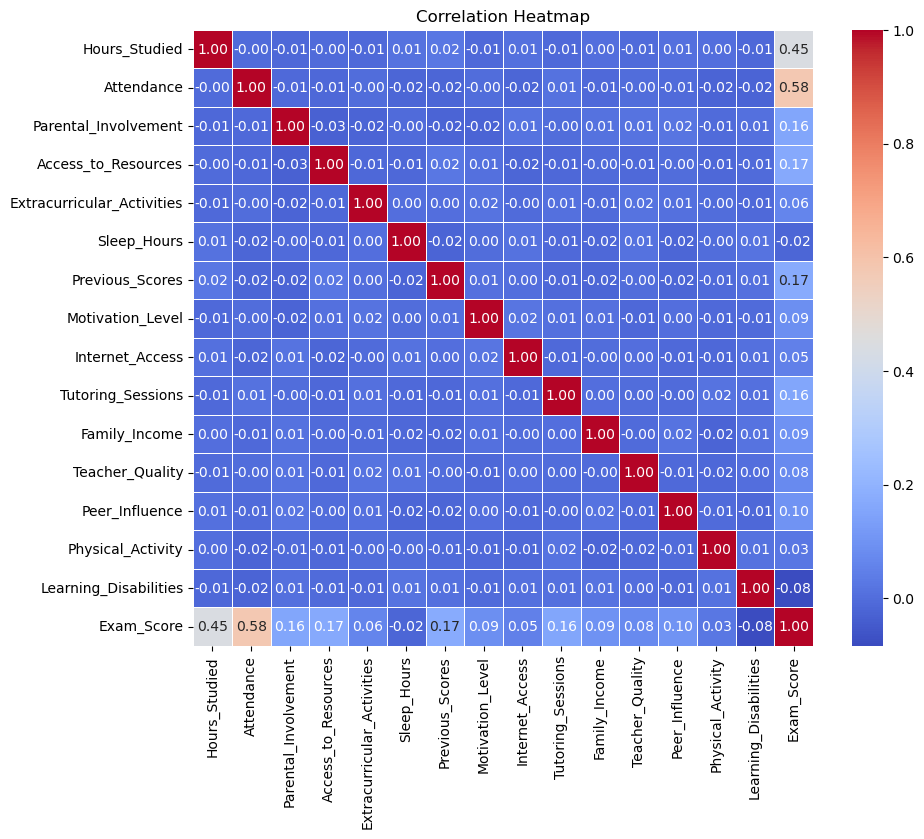

In [40]:
# Finding correlation between each covariates and target variates(exam score) to find which data we correlate and needed
# for further more preprocessing
numeric_cols = df_cleaned.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

As we can see there is only 2 covariates that has some relevancy to the target variable(Exam_Score) so we decided to use
Hours_Studied and Attendance as covariates

In [41]:
Q1 = df_cleaned['Hours_Studied'].quantile(0.25)
Q3 = df_cleaned['Hours_Studied'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_Studied = df_cleaned[(df_cleaned['Hours_Studied'] < lower_bound) | (df_cleaned['Hours_Studied'] > upper_bound)]

In [42]:
outliers_Studied.shape

(40, 20)

In [43]:
Q1 = df_cleaned['Attendance'].quantile(0.25)
Q3 = df_cleaned['Attendance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_Attendance = df_cleaned[(df_cleaned['Attendance'] < lower_bound) | (df_cleaned['Attendance'] > upper_bound)]

In [44]:
outliers_Attendance.shape

(0, 20)

In [45]:
Q1 = df_cleaned['Exam_Score'].quantile(0.25)
Q3 = df_cleaned['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_Exam = df_cleaned[(df_cleaned['Exam_Score'] < lower_bound) | (df_cleaned['Exam_Score'] > upper_bound)]

In [46]:
outliers_Exam.shape

(103, 20)

In [47]:
df_cleaned.shape

(6378, 20)

As the total outliers of Hours Studied, Attendance, and Exam_Score is less than 10% I decided to remove all outliers
this is to eliminate all biases that might happend

In [48]:
# Calculate the IQR for Exam_Score
Q1_exam = df_cleaned['Exam_Score'].quantile(0.25)
Q3_exam = df_cleaned['Exam_Score'].quantile(0.75)
IQR_exam = Q3_exam - Q1_exam
lower_bound_exam = Q1_exam - 1.5 * IQR_exam
upper_bound_exam = Q3_exam + 1.5 * IQR_exam

# Calculate the IQR for Hours_Studied
Q1_hours = df_cleaned['Hours_Studied'].quantile(0.25)
Q3_hours = df_cleaned['Hours_Studied'].quantile(0.75)
IQR_hours = Q3_hours - Q1_hours
lower_bound_hours = Q1_hours - 1.5 * IQR_hours
upper_bound_hours = Q3_hours + 1.5 * IQR_hours

# Filter rows based on Exam_Score IQR
df_no_outliers = df_cleaned[(df_cleaned['Exam_Score'] >= lower_bound_exam) & (df_cleaned['Exam_Score'] <= upper_bound_exam)]

# Filter rows based on Hours_Studied IQR
df_clear = df_no_outliers[(df_no_outliers['Hours_Studied'] >= lower_bound_hours) & (df_no_outliers['Hours_Studied'] <= upper_bound_hours)]

# Print the shapes
print(f"Original DataFrame shape: {df_cleaned.shape}")
print(f"Original DataFrame shape: {df_no_outliers.shape}")
print(f"Filtered DataFrame shape: {df_clear.shape}")

Original DataFrame shape: (6378, 20)
Original DataFrame shape: (6275, 20)
Filtered DataFrame shape: (6248, 20)


In [49]:
df_clear.head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,0,7,73,0,1,0,0,1.0,Public,2,3,0,High School,Near,Male,67
1,19,64,0,1,0,8,59,0,1,2,1,1.0,Public,0,4,0,College,Moderate,Female,61
2,24,98,1,1,1,7,91,1,1,2,1,1.0,Public,1,4,0,Postgraduate,Near,Male,74
3,29,89,0,1,1,8,98,1,1,1,1,1.0,Public,0,4,0,High School,Moderate,Male,71
4,19,92,1,1,1,6,65,1,1,3,1,2.0,Public,1,4,0,College,Near,Female,70
5,19,88,1,1,1,8,89,1,1,3,1,1.0,Public,2,3,0,Postgraduate,Near,Male,71
6,29,84,1,0,1,7,68,0,1,1,0,1.0,Private,1,2,0,High School,Moderate,Male,67
7,25,78,0,2,1,6,50,1,1,1,2,2.0,Public,0,2,0,High School,Far,Male,66
8,17,94,1,2,0,6,80,2,1,0,1,0.0,Private,1,1,0,College,Near,Male,69
9,23,98,1,1,1,8,71,1,1,0,2,2.0,Public,2,5,0,High School,Moderate,Male,72


After finding all the necessary covariates and target variable, we can move on to model training

# Training Model and Evaluation

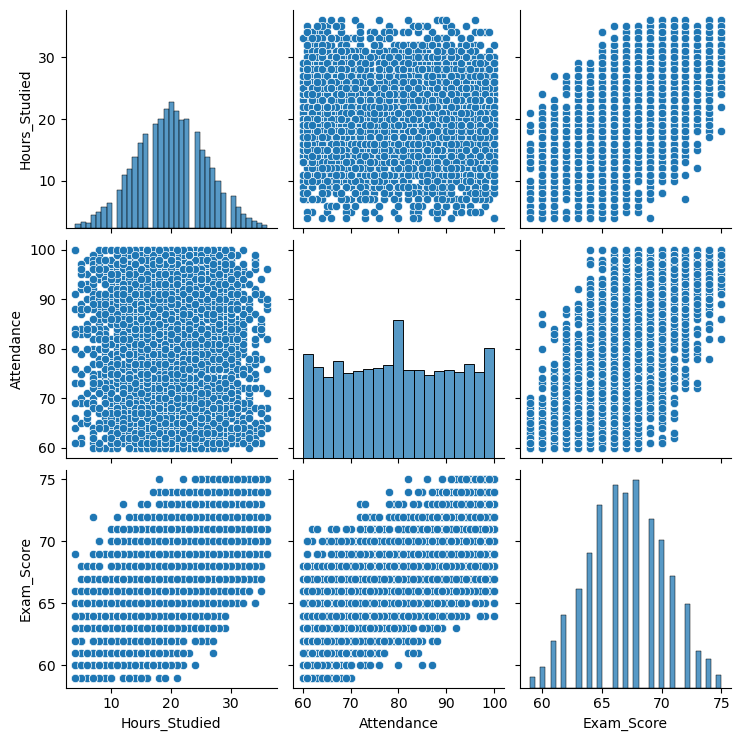

In [50]:
sns.pairplot(df_clear[['Hours_Studied', 'Attendance', 'Exam_Score']])

As we can here see from the plot in Hours_Studied with Exam_Score and Attendance with Exam_Score there is a linear tendency
given this information we decided to make a linear regression model

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

In [52]:
# Define the feature (covariates) and target (dependent) variable
X = df_clear[['Attendance', 'Hours_Studied']]  # Independent variables (features)
y = df_clear['Exam_Score']  # Dependent variable (target)

In [53]:
# Split the data with training 80% and testing 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# Create the linear regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(X_train, y_train)
# Predict the exam scores using the test set
y_pred = model.predict(X_test)

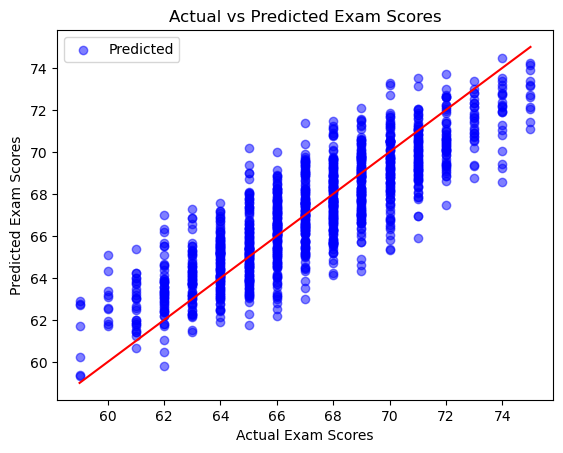

In [55]:
# Plot the predicted vs. actual exam scores
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='-')  # Ideal line
plt.xlabel('Actual Exam Scores')
plt.ylabel('Predicted Exam Scores')
plt.title('Actual vs Predicted Exam Scores')
plt.legend()
plt.show()

In [56]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
# Calculate R-squared (coefficient of determination)
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

Mean Squared Error: 2.94341212911291
R-squared: 0.7171645338516248
Root Mean Squared Error (RMSE): 1.7156375284753216
Mean Absolute Error (MAE): 1.3777494506474863


With exam score being 0-100 an MSE of 2.9 can be considered low that means predicted score are close to actual score

With R-squared of 0.71 this model can explain roughly 71.7% of the exam score(71,7% of the variance in the exam score can
can be explained by Hours_Studied and Attendance)

RMSE of 1.71 on average, the predicted exam scores are off by 1.71 points from the actual exam scores.

MAE of 1.37 means that, on average, the predicted exam scores are off by 1.37 points from the actual exam scores.
because exam score range from 0-100 this indicate a good model performance

The visualised model goals is to evaluate Predicted Exam Scored with Actual Exam Scores by comparing predicted value with actual value

In [57]:
# View model coefficients and intercept
print(f'Intercept: {model.intercept_}')
print(f'Coefficients: {model.coef_}')

Intercept: 45.575611002054494
Coefficients: [0.19659363 0.28850336]


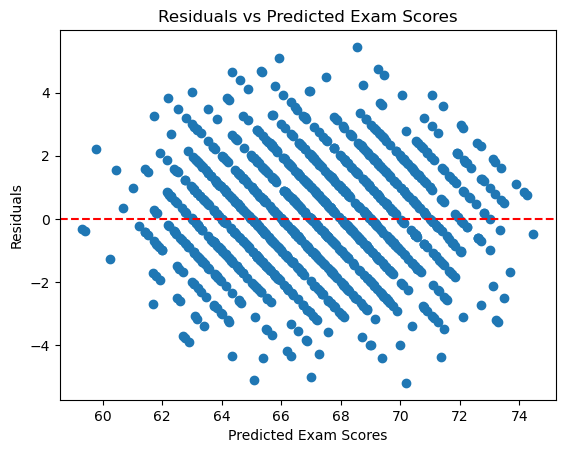

In [58]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Exam Scores')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Exam Scores')
plt.show()

From the residual plot we can see that it scatters evenly with no emerging pattern seen which is good since that means
regression model has captured relationship between the predictor and target without significant bias.